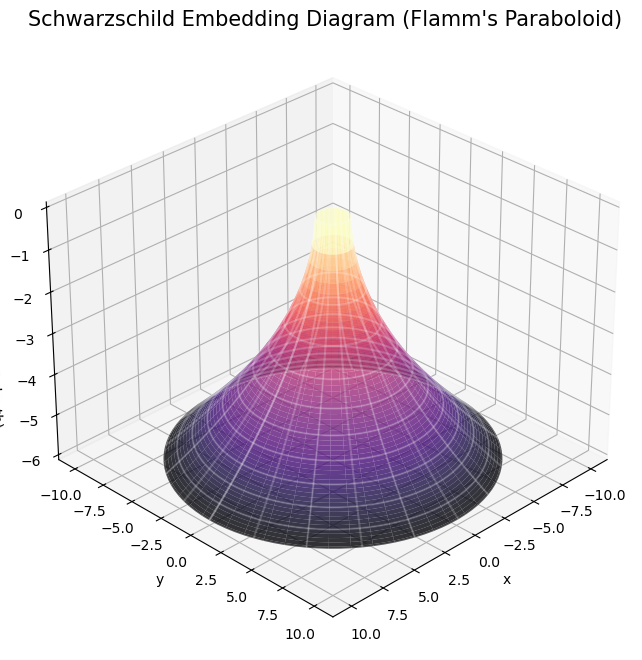

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_schwarzschild_embedding():
    # シュバルツシルト半径を1とする
    rs = 1.0
    
    # rの範囲: rsより少し大きいところから開始（ゼロ除算回避）
    r = np.linspace(rs + 0.01, 10 * rs, 100)
    phi = np.linspace(0, 2 * np.pi, 100)
    
    R, PHI = np.meshgrid(r, phi)
    
    # フラムの放物面の式: z(r) = 2 * sqrt(rs * (r - rs))
    # 上側と下側に対称に描画するためにプラスマイナスを用意
    Z = 2 * np.sqrt(rs * (R - rs))
    
    # 円筒座標から直交座標へ変換
    X = R * np.cos(PHI)
    Y = R * np.sin(PHI)
    
    # プロット作成
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # ワイヤーフレームで描画（上側）
    ax.plot_surface(X, Y, -Z, cmap='magma', alpha=0.8, edgecolor='none')
    
    # グリッド線を追加（重力井戸の深さを強調）
    ax.plot_wireframe(X, Y, -Z, color='white', alpha=0.2, rstride=5, cstride=10)

    # 装飾
    ax.set_title("Schwarzschild Embedding Diagram (Flamm's Paraboloid)", fontsize=15)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z (Spatial curvature depth)")
    ax.set_zlim(-6, 0)
    
    # 視点の調整
    ax.view_init(elev=30, azim=45)
    
    plt.show()

if __name__ == "__main__":
    plot_schwarzschild_embedding()

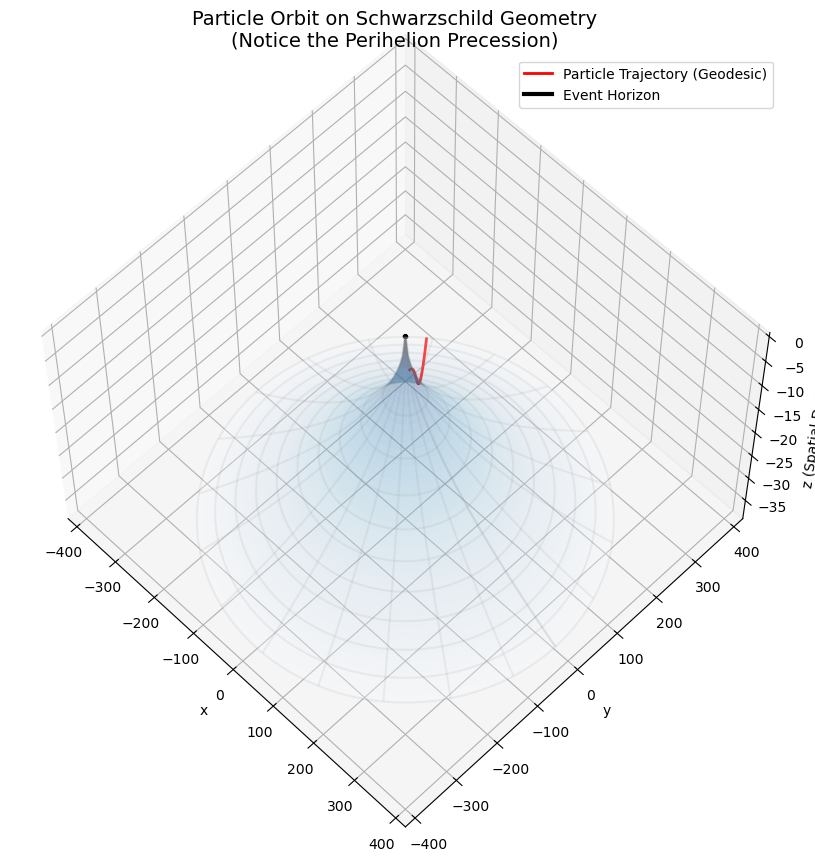

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import odeint

def solve_geodesic():
    # --- 1. パラメータ設定 ---
    rs = 1.0  # シュバルツシルト半径
    
    # 初期条件
    r0 = 10.0      # 初期位置（中心からの距離）
    vr0 = 0.0      # 初期の半径方向の速度（0=近日点または遠日点からスタート）
    phi0 = 0.0     # 初期角度
    
    # 角運動量 L (この値が軌道の形状を決めます)
    # ニュートン力学に近い円軌道より少しずらすことで、歳差運動を強調します
    L = 4.0        
    
    # シミュレーション時間（固有時）
    tau = np.linspace(0, 1600, 5000)

    # --- 2. 運動方程式の定義 (GRの有効ポテンシャルから導出) ---
    # 状態ベクトル y = [r, dr/dtau, phi]
    def deriv(y, tau):
        r, vr, phi = y
        
        # 半径方向の加速度 (一般相対論項: -1.5 * rs * L^2 / r^4 が追加される)
        # d2r/dtau^2 = -GM/r^2 + L^2/r^3 - 3GM*L^2/c^2/r^4
        # ここでは rs = 2GM, c=1 としています
        ar = -0.5 * rs / (r**2) + (L**2) / (r**3) - 1.5 * rs * (L**2) / (r**4)
        
        # 角度方向の速度
        dphi = L / (r**2)
        
        return [vr, ar, dphi]

    # --- 3. 微分方程式を解く ---
    y0 = [r0, vr0, phi0]
    sol = odeint(deriv, y0, tau)
    
    r_path = sol[:, 0]
    phi_path = sol[:, 2]

    # --- 4. 埋め込み図（空間の曲面）のデータ作成 ---
    # 軌道の範囲に合わせてグリッドを作成
    r_grid = np.linspace(rs + 0.1, np.max(r_path) + 5, 100)
    p_grid = np.linspace(0, 2 * np.pi, 100)
    R, P = np.meshgrid(r_grid, p_grid)
    
    # フラムの放物面の高さ z(r)
    Z_surf = 2 * np.sqrt(rs * (R - rs))
    X_surf = R * np.cos(P)
    Y_surf = R * np.sin(P)

    # --- 5. 軌道を3次元空間にマッピング ---
    # 粒子が動く場所の「高さ」を計算
    # 注意: r < rs になると計算できないためフィルタリング
    valid_mask = r_path > rs
    r_path = r_path[valid_mask]
    phi_path = phi_path[valid_mask]
    
    z_path = 2 * np.sqrt(rs * (r_path - rs))
    x_path = r_path * np.cos(phi_path)
    y_path = r_path * np.sin(phi_path)

    # --- 6. プロット ---
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 空間の曲面（ワイヤーフレーム）
    ax.plot_surface(X_surf, Y_surf, -Z_surf, cmap='Blues', alpha=0.3, edgecolor='none')
    ax.plot_wireframe(X_surf, Y_surf, -Z_surf, color='gray', alpha=0.1, rstride=5, cstride=10)

    # 粒子の軌道（赤い線）
    ax.plot(x_path, y_path, -z_path, color='red', linewidth=2, label='Particle Trajectory (Geodesic)')
    
    # ブラックホールの中心（事象の地平線）
    # rsの位置に黒い円を描く
    theta = np.linspace(0, 2*np.pi, 100)
    x_bh = rs * np.cos(theta)
    y_bh = rs * np.sin(theta)
    z_bh = np.zeros_like(x_bh) # 地平線は喉の最深部（この図ではz=0）
    ax.plot(x_bh, y_bh, z_bh, color='black', linewidth=3, label='Event Horizon')

    # 装飾
    ax.set_title("Particle Orbit on Schwarzschild Geometry\n(Notice the Perihelion Precession)", fontsize=14)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z (Spatial Depth)")
    ax.set_zlim(np.min(-Z_surf), 0)
    ax.legend()
    
    # 真上から少し斜めに見る
    ax.view_init(elev=60, azim=-45)

    plt.show()

if __name__ == "__main__":
    solve_geodesic()